
<font color=#009afa size=50>Visualisation of Data</font>

<font size=50>DAT5001 - Satellites</font>

CHECK THIS BELOW!

|**Assessment Code:** |PRES1|
|---|---|
|**Author:**|Tom Rowan, ST20285213|
|**Course:**| DAT5001_S2_25|
|**Course Tutor:**| ***** Dr. Imtiaz *****|

For this assignment, students will use content from the PRES1 presentation to deliver an individual report.  The report will include following parts:

Part 1 (Introduction): Outlining the issue with background information. Questions/Hypothesis/Objective/Message/Goal related to the issue addressed by this report.  

Part 2 (Materials and Methods): Description of data which includes data collection, cleaning and transformation procedures along with description about the data context/metadata.  Design principles and tools used to create the storyboard and infographics. 

Part 3 (Results): Figures and description narrating the issue in detail, particularly summarised view (both spatial and temporal) of the issue across different locations and time points as well as comparative view.   

Part 4 (Discussion): Identification of key bottlenecks associated with the issue evident from the results.  Also provide rationale for the Questions /Hypothesis /Objective /Message /Goal.

## Part 1

Issues:
- Kessler Syndrome (https://aquarid.physics.uwo.ca/kessler/Kessler%20Syndrome-AAS%20Paper.pdf)
- Rocket Launches - CO2 impact

Falcon 9 Rocket (https://sma.nasa.gov/LaunchVehicle/assets/spacex-falcon-9-data-sheet.pdf)

Copilot says:

A single SpaceX Falcon 9 launch uses approximately 507,500 kilograms (about 507.5 metric tonnes) of propellant, which consists of:

RP-1 (rocket-grade kerosene): ~112,184 kg
Liquid Oxygen (LOX): ~395,316 kg

This total is based on the Falcon 9 Full Thrust (Block 5) version, which is the current operational variant. The rocket is a two-stage launch vehicle, and both stages use RP-1 and LOX as propellants.
Breakdown by Stage

First Stage:

Propellant mass: ~395,700 kg
Burn time: ~162 seconds
Engines: 9 Merlin 1D


Second Stage:

Propellant mass: ~92,670 kg
Burn time: ~397 seconds
Engine: 1 Merlin Vacuum



These figures are derived from technical specifications and performance analyses. [wevolver.com]
Environmental Impact
Each Falcon 9 launch emits approximately 336,552 kg of CO₂, based on the combustion of RP-1 kerosene. [championtraveler.com]
Sources

Wevolver Falcon 9 Block 5 Specs [wevolver.com]
Champion Traveler CO₂ Analysis [championtraveler.com]
Wikipedia Falcon 9 Overview [en.wikipedia.org]

As of October 2025, SpaceX typically launches 28 Starlink satellites per Falcon 9 mission. [extremetech.com], [arstechnica.com], [msn.com]
This number has decreased over time due to the satellites becoming larger and more capable. Earlier in the Starlink program (around 2019–2020), Falcon 9 launches carried up to 60 satellites per flight. However, the current V2 Mini satellites are more advanced and heavier, which limits the number that can be carried per launch.

https://www.extremetech.com/aerospace/spacex-sends-10000th-starlink-satellite-into-orbit-with-latest-falcon-9




 D.J. Kessler and B.G. Cour-Palais, "Collision Frequency of Artificial Satellites: The Creation of a Debris Belt", Journal of Geophysical Research, Vol. 83, No. A6, pp. 2637-2646, June 1, 1978. 
Available at: https://www.freelists.org/archives/arocket/05-2025/pdfhf1FIX9bCw.pdf
Accessed 22/10/2025




## Code for Graphs below

In [359]:
# Install Requirements Using Pip
%pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 19.7 MB/s  0:00:00 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [406]:
# Standard Libraries
import json
import random
from datetime import datetime

# Pandas and numpy
import pandas as pd
import numpy as np

# Matplot Lib
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.pyplot import figure
%matplotlib inline

# Seaborn Graphs
import seaborn as sns

# Cartopy Maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Geopandas
import geopandas as gpd

# Pycountry 
import pycountry

# Tabulate
from tabulate import tabulate

# Colorama
from colorama import Fore, Back, Style

# Requests
import requests

# Beautifulsoup
from bs4 import BeautifulSoup

# Do not print warnings!
import warnings
warnings.filterwarnings('ignore')

In [40]:
re_df = pd.read_csv('../../datasets/Reentry_History_Spreadsheet_09-29-25.csv')
sat_df = pd.read_csv('../../datasets/UCS-Satellite-Database 5-1-2023.csv')

In [41]:
re_df.columns

Index(['Observed Reentry Date (UTC)', 'Object Name',
       'International Designator', 'SSN', 'TLE Epoch (UTC)',
       'Aerospace Reentry Prediction (UTC)',
       'Aerospace Stated Uncertainty 20% Rule (+/- hrs)', 'Country of Origin',
       'Type', 'Sighting Location', 'Sighting Latitude', 'Sighting Longitude',
       'Debris Recovery Location', 'Recovery Latitude', 'Recovery Longitude'],
      dtype='object')

In [42]:
sat_df.columns

Index(['Name of Satellite, Alternate Names',
       'Current Official Name of Satellite', 'Country/Org of UN Registry',
       'Country of Operator/Owner', 'Operator/Owner', 'Users', 'Purpose',
       'Detailed Purpose', 'Class of Orbit', 'Type of Orbit',
       'Longitude of GEO (degrees)', 'Perigee (km)', 'Apogee (km)',
       'Eccentricity', 'Inclination (degrees)', 'Period (minutes)',
       'Launch Mass (kg.)', ' Dry Mass (kg.) ', 'Power (watts)',
       'Date of Launch', 'Expected Lifetime (yrs.)', 'Contractor',
       'Country of Contractor', 'Launch Site', 'Launch Vehicle',
       'COSPAR Number', 'NORAD Number', 'Comments', 'Unnamed: 28',
       'Source Used for Orbital Data', 'Source', 'Source.1', 'Source.2',
       'Source.3', 'Source.4', 'Source.5', 'Source.6', 'Unnamed: 37',
       'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41',
       'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45',
       'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49',


NB: Need to clean the data so that we only have satellites, removing the rockets and other debris.

In [43]:
# Join raw data set
df = sat_df.set_index('COSPAR Number').join(re_df.set_index('International Designator'))
df.reset_index(inplace=True)

In [44]:
display (df.loc[df['COSPAR Number'] == '2021-009BM'])

,COSPAR Number,"Name of Satellite, Alternate Names",Current Official Name of Satellite,Country/Org of UN Registry,Country of Operator/Owner,Operator/Owner,Users,Purpose,Detailed Purpose,Class of Orbit,...,Aerospace Reentry Prediction (UTC),Aerospace Stated Uncertainty 20% Rule (+/- hrs),Country of Origin,Type,Sighting Location,Sighting Latitude,Sighting Longitude,Debris Recovery Location,Recovery Latitude,Recovery Longitude
3922,2021-009BM,Starlink-2025,Starlink-2025,USA,USA,SpaceX,Commercial,Communications,NaN,LEO,...,2025-03-25T04:08:05.960000Z,1.0,UNITED STATES OF AMERICA,Payload,"California and Utah, USA",38.83,-119.63,NaN,NaN,NaN


In [45]:
payload_count = df['Type'].value_counts().reset_index()
payload_count.columns = ['Type', 'Count']
display(payload_count)

,Type,Count
0,Payload,764
1,PAYLOAD,13
2,Unknown,11
3,R/B,3
4,DEBRIS,2
5,ROCKET BODY,1


In [46]:
contractor_counts = df['Contractor'].value_counts().reset_index()
contractor_counts.columns = ['Contractor', 'Count']
display(contractor_counts)

,Contractor,Count
0,SpaceX,3997
1,OneWeb Satellites/Airbus,502
2,"Planet Labs, Inc.",199
3,China Academy of Space Technology (CAST),182
4,Spire Global,135
...,...,...
572,Care Weather Technologies/Brigham Young Univer...,1
573,Visiona Tecnologia Espacial,1
574,China Academy of Science,1
575,China Great Wall Industry Corporation (CGWIC),1


<Axes: xlabel='Contractor'>

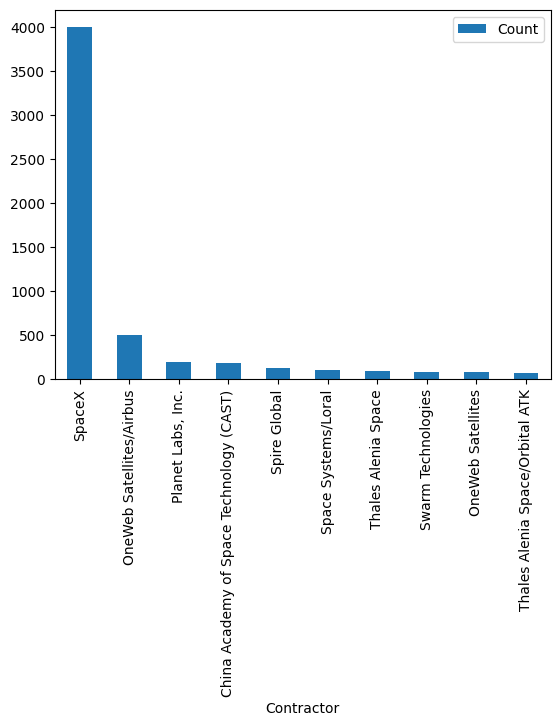

In [47]:
contractor_counts.head(10).plot(kind='bar', x='Contractor')

## Feature Engineering

In [48]:
df['Year of Launch'] = df['Date of Launch'].astype(str).str[-4:]
#df['Year of Launch'] = df['Year of Launch'].astype(int)

In [49]:
df.to_csv('working_dataset.csv')

In [50]:
year_counts = df['Year of Launch'].value_counts().reset_index().sort_values(by='Year of Launch')
year_counts.columns = ['Year of Launch', 'Count']
year_counts.dropna
display(year_counts)

,Year of Launch,Count
34,/018,1
33,1974,1
37,1988,1
35,1989,1
31,1990,2
38,1991,1
36,1992,1
28,1993,3
32,1994,2
27,1995,4


<Axes: xlabel='Year of Launch'>

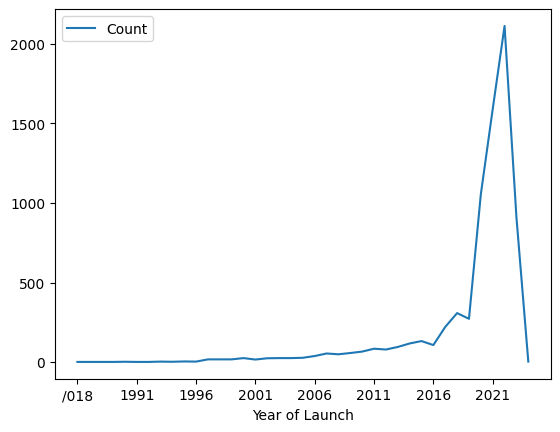

In [51]:
year_counts.plot(kind='line', x='Year of Launch')

## Scraping More Data

https://www.n2yo.com/satellite/?s=65909

API Key:  6UGT66-UVJVBR-RE9FV6-5L9M

Reference:
https://www.n2yo.com/satellite-article/How-many-satellites-can-we-safely-fit-in-Earth-orbit/86

In [52]:
def fetch_proxy_list (proxy_list_url="https://raw.githubusercontent.com/proxifly/free-proxy-list/refs/heads/main/proxies/countries/GB/data.txt"):

    # Fetch the list of proxies
    all_proxies = []
    http_proxies = []

    # Wrap in a try/except/finally block
    try:
        print (Fore.CYAN + "[Info] Fetching list of proxies." + Fore.RESET)
        response = requests.get(proxy_list_url)
        if response.status_code == 200:
            all_proxies = response.text.split("\n")

            for proxy in all_proxies:
                if proxy.startswith("http"):
                    http_proxies.append(proxy)
        else:
            print (Fore.RED + "[Error] Failed to fetch list of proxies.")
            print (f"[Error] {response.status_code}" + Fore.RESET) 

    except Exception as e:
        print (Fore.RED + "[Error] Error fetching proxies." )
        print (f"[Error] {e}" + Fore.RESET)

    finally:
        print (Fore.YELLOW + f"[Info] Got {len(http_proxies)} proxies." + Fore.RESET)
        return http_proxies


# Get a random proxy from the list
def get_random_proxy (http_proxies):
    return random.choice(http_proxies)

In [53]:
base_url = "https://www.n2yo.com/satellite/?s="
last = 65909 # maybe more - detect failure to find a satellite

In [54]:
def parse_satinfo(html):

    soup = BeautifulSoup(html, 'html.parser', from_encoding='utf-8')
    satinfo_div = soup.find('div', id='satinfo')

    if satinfo_div:

        sat_data = {}

        # Extract satellite name
        h1 = satinfo_div.find('h1')
        sat_data['name'] = h1.text.strip() if h1 else None

        # Extract all <b> tags and their following text
        for b_tag in satinfo_div.find_all('b'):
            key = b_tag.text.strip().replace(':', '')
            if not key.startswith('Note'):   
                if key == "Launch date":
                    # Look for the next <a> tag after the <b> tag
                    a_tag = b_tag.find_next('a')
                    value = a_tag.text.strip() if a_tag else None
                else:    
                    value = b_tag.next_sibling
            
                if value:
                    sat_data[key] = value.strip().replace(': ', '')
            #else:
                #sat_data.pop(key)

    return sat_data



In [55]:
sat_data_combined = []

proxy_list = fetch_proxy_list()
#65910
for page in range (1, 65910):  
    
    # Get a random proxy from the list
    proxy = get_random_proxy(proxy_list)
    proxies = {'http': proxy}

    url = base_url + str(page)
    
    # Fetch the page
    response = requests.get (url=url, proxies = proxies)
    satellite_info = parse_satinfo(response.content)
    sat_data_combined.append(satellite_info)
    print ('.', end='')
    if (page % 100 == 0):
        print (page)


[Info] Fetching list of proxies.
[Info] Got 19 proxies.
..................

KeyboardInterrupt: 

In [56]:
new_sat_df = pd.DataFrame(sat_data_combined)
new_sat_df.head(20)
new_sat_df.to_csv('65k_satellites.csv')

https://www.planet4589.org/space/gcat/index.html

tsv Files: 

SatCat: https://www.planet4589.org/space/gcat/tsv/cat/satcat.tsv
Payload: https://www.planet4589.org/space/gcat/tsv/cat/psatcat.tsv   -- enrich with this data
Aux cat: ??? https://www.planet4589.org/space/gcat/tsv/cat/auxcat.tsv
Org Data: https://www.planet4589.org/space/gcat/tsv/tables/orgs.tsv
Launch sites: https://www.planet4589.org/space/gcat/tsv/tables/sites.tsv

Documentation: https://www.planet4589.org/space/gcat/pdf/doc.pdf

Citation is "McDowell, J, 2020: General Catalog of Artificial Space Objects, https://planet4589.org/space/gcat"
Accessed 24/10/2025

Main Object Catalogs
VIII.2.1 Primary Orbital Object Catalogs
VIII.2.1.1 The Standard (S) Satellite Catalog
Since the late 1950s the US government has maintained a catalog of satellites (often referred to as the SATCAT). Each
satellite is given a sequential number (1 was the rocket stage from the first Sputnik). These numbers are sometimes
referred to as SSN numbers.
In GCAT, each entry in the S catalog (Standard Satellite Catalog or satcat) corresponds directly to the
corresponding entry in the US catalog; entry S00001 corresponds to SSN 1, entry S40000 corresponds to SSN 40000.
The S catalog contains additional metadata not present in the US catalog, described later in this chapter. Note that I
will use SATCAT in upper case to refer to the US catalog, while the lower case version will always refer to GCAT’s
S catalog.
By convention I render entries 1-99999 in each catalog with 5 digits, in this case S00001 to S99999. I then
jump to 9 digits for objects 000100000 onwards (S000100000 in this case). I am optimistic that we won’t reach
S999999999 before I retire, so that’ll be Somebody Else’s Problem.
There are, as always, complications. Not infrequently, the SSN numbers associated with two space objects
are swapped, or an SSN number is reassigned to a different object and the previously assigned object is now not
in the catalog. However, archival TLE (Two Line Element) sets for the previous object remain associated with the
same catalog number, potentially causing confusion. Although I would rather not reassign numbers, in the interests
of practical compatibility the S catalog entry corresponds to the object MOST RECENTLY ASSOCIATED with that
catalog number (and the GCAT is updated as required to reflect this).
The SSN number is really associated with an object tracked by the US space tracking team (currently the 18th
Space Control Squadron and associated organizations). The set of TLEs associated with that catalog number, for the
most part, define the SSN. The association of that catalog number with a physical object (satellite, rocket, debris) is
an inference. Sometimes I disagree with the association made, and the S catalog reflects that. The harder problem
is when you have, say, 3 SSN tracked objects and three known payloads, but you have no idea which is which. This
can occur, for example, when three externally similar cubesats deployed from the same vehicle immediately fail, so
even the satellite owners don’t know which is which. In this case the SATCAT will just have them as ’OBJECT C’,
etc., and not attempt to make an identification. I prefer to make an arbitrary assignment of the three objects to catalog
numbers but flag the assignments as uncertain. This lets me enter all the metadata such as country, owner, name etc.
and so statistical counts such as number of payloads associated with a given country will come out right.
Some satellites are made up of several attached sections. When I deem that these separate sections are of
sufficient interest to deserve their own catalog entry (for example because their metadata are interestingly different)
I create additional entries in the auxcat (see below), and choose one of the sections to be associated with the S entry.
As an example, for CORONA satellites both the CORONA payload and the attached Agena rocket stage, as well as
any Agena aft rack attached payloads, get catalog entries. In such cases the S entry is given to the payload; metadata
includes the information that the CORONA and the Agena remained attached until reentry.
The SATCAT associates debris objects with a particular launch but does not identify them in detail; again, I
make my best guess as to the nature and origin of particular debris objects.
The US catalog is coy about certain military and intelligence satellites belonging to the US and its allies.
Usually a cover name (e.g. USA 304) and a launch date are provided, but no orbital data or reentry date. Since I do
not have access to secret information, I am free to speculate. Usually it’s not very hard and identifications of secret
satellites with particular programs and orbits mostly have a high degree of confidence.

 - LDate (Launch Date).
 - SDate Separation Date (or Phase Start Date).
 - DDate Descent Date (or Phase End Date).
 - ODate Orbit Epoch Date (Epoch of canonical orbital data)
 - Status: O, R ... ?
 - Length, Diameter, Span, 
 - Piece COSPAR Designation
 - Name Name in UN satellite registry
 - Class (Amateur, Business, Civil (Gov, non-mil), Defence (Gov, mil or intel))

Category:

- AST Astronomy
- BIO Biology and life sciences
- CAL Calibration (for atmospheric density, space surveillance radars, etc). Usually passive.
- COM Communications
- EDU Educational purposes.
- EOSCI Earth observing science, except imaging
- EW Missile early warning, including ballistic missile defence tracking
- GEOD Geodesy
- IMG Imaging (optical), except meteorology
- IMG-R Imaging (radar)
- INF Infrastructure (support structures, deployers etc)
- MET Meteorology (imaging)
- MET-RO Meteorology (radio occultation)
- MGRAV Microgravity experiments
- MISC Miscellaneous (e.g. burial services)
- NAV Navigation, positioning and timing
- PLAN Deep space related mission
- RB Rocket body (rocket upper stage)
- RV Reentry vehicle
- SCI Scientific studies, except astronomy and Earth observing
- SIG Signals intelligence
- SS Spaceship, i..e human spaceflight related (including cargo ships)
- TARG Target for missile defense or antisatellite tests
- TECH Technology and training
- WEAPON Weapon, including antisatellite experiment and FOB



In [415]:
#satcat_df = pd.read_csv('../../datasets/satcat.tsv', sep='\t')
satcat_df = pd.read_csv('https://www.planet4589.org/space/gcat/tsv/cat/satcat.tsv', sep='\t')
pay_df = pd.read_csv('https://www.planet4589.org/space/gcat/tsv/cat/psatcat.tsv', sep='\t')
orgs_df = pd.read_csv('https://www.planet4589.org/space/gcat/tsv/tables/orgs.tsv', sep='\t')
lsite_df = pd.read_csv('https://www.planet4589.org/space/gcat/tsv/tables/sites.tsv', sep='\t')

In [416]:
satcat_df.shape

(66114, 42)

In [417]:
satcat_df.sample(n=10)

,#JCAT,Satcat,Launch_Tag,Piece,Type,Name,PLName,LDate,Parent,SDate,...,ODate,Perigee,PF,Apogee,AF,Inc,IF,OpOrbit,OQUAL,AltNames
18816,S18816,18816,1978-014,1978-014G,D J,deb Kyokko,KM part?,1978 Feb 4,S10664,1978 Feb 4 0805,...,1987 Oct 31,1073,,4007,,64.93,,MEO,-,-
39004,S39004,39004,2012-025,2012-025L,D P,deb H-2A F21,-,2012 May 17,S38341,2012 Nov?,...,2012 Nov 19,639,,718,,98.17,,LEO/S,-,-
28892,S28892,28892,2005-043,2005-043C,P,UWE-1,UWE-1,2005 Oct 27,S28894,2005 Oct 27 0830?,...,2005 Nov 3,682,,708,,98.18,,LEO/S,-,-
37279,S37279,37279,1993-036,1993-036BHT,D I,deb Kosmos-2251,-,1993 Jun 16,S22675,2009 Feb 10 1656,...,2011 Jan 3,458,,762,,73.86,,LEO/I,-,-
43275,S43275,43275,2018-034,2018-034A,P,Yaogan 31 hao 01 zu 01 xing,Jianbing-8 06 zu 01 xing,2018 Apr 10,S43278,2018 Apr 10 0448?,...,2018 Apr 11,1086,,1099,,63.41,,LEO/I,-,-
10567,S10567,10567.0,1977-121,1977-121J,D W,deb Kosmos-970,-,1977 Dec 21,S10531,1977 Dec 21 1710,...,1993 Aug 7,977.0,,1137,,65.79,,LEO/I,-,-
35394,S35394,35394,1983-004,1983-004D,D J,deb IRAS,-,1983 Jan 26,S13777,2009 Jun?,...,2009 Jun 21,690,,792,,99.67,,LEO/S,-,-
52321,S52321,52321,2022-043,2022-043B,C A,Siwei adapter part?,-,2022 Apr 29,S52323,2022 Apr 29 0423?,...,2022 Apr 29,484,,501,,97.47,,LLEO/S,-,-
51406,S51406,51406,1982-092,1982-092BJC,D W,deb Kosmos-1408,-,1982 Sep 16,S13552,2021 Nov 15 0250?,...,2022 Jan 27,319,,330,,82.67,,LLEO/I,-,-
41754,S41754,41754,2000-078,1998-067KE,C H E,EVA-37 debris?,-,1998 Nov 20,A06373*,2016 Sep 1 1800?,...,2016 Sep 8,400,,404,,51.64,,LLEO/I,-,-


In [418]:
satcat_df.columns

Index(['#JCAT', 'Satcat', 'Launch_Tag', 'Piece', 'Type', 'Name', 'PLName',
       'LDate', 'Parent', 'SDate', 'Primary', 'DDate', 'Status', 'Dest',
       'Owner', 'State', 'Manufacturer', 'Bus', 'Motor', 'Mass', 'MassFlag',
       'DryMass', 'DryFlag', 'TotMass', 'TotFlag', 'Length', 'LFlag',
       'Diameter', 'DFlag', 'Span', 'SpanFlag', 'Shape', 'ODate', 'Perigee',
       'PF', 'Apogee', 'AF', 'Inc', 'IF', 'OpOrbit', 'OQUAL', 'AltNames'],
      dtype='object')

In [419]:
columns_to_keep = ['Piece', 'Type', 'Name', 'LDate', 'DDate', 'Status', 'Owner', 'State', 'Manufacturer', 'Mass', 'Length', 'Diameter', 'Span', 'Shape', 'Perigee', 'Apogee', 'Inc']

sdf = satcat_df[columns_to_keep]
sdf.columns

Index(['Piece', 'Type', 'Name', 'LDate', 'DDate', 'Status', 'Owner', 'State',
       'Manufacturer', 'Mass', 'Length', 'Diameter', 'Span', 'Shape',
       'Perigee', 'Apogee', 'Inc'],
      dtype='object')

Feature engineering with dates.

In [ ]:
sdf['LDate'] = sdf['LDate'].replace("-", np.nan)  # Shouldn't be any!
sdf = sdf.dropna(subset=['LDate'])
sdf['DDate'] = sdf['DDate'].replace("-", np.nan)

# Modify date columns
# Convert to datetime format
sdf['LDate'] = pd.to_datetime(sdf['LDate'], errors='coerce')
sdf['DDate'] = pd.to_datetime(sdf['DDate'], errors='coerce')

# Create a Year of Launch and Descent
sdf['LYear'] = sdf['LDate'].dt.year.astype('Int64')
sdf['DYear'] = sdf['DDate'].dt.year.astype('Int64')

# Replace null DDate with today's date
today = pd.Timestamp(datetime.today())
sdf['EffectiveDDate'] = sdf['DDate'].fillna(today)

# Calculate lifetime
delta = sdf['EffectiveDDate'] - sdf['LDate']
sdf['ActiveDays'] = delta.dt.days
sdf['ActiveMonths'] = (delta.dt.days / 30.44).round(1)  # Approximate month length
sdf['ActiveYears'] = (delta.dt.days / 365.25).round(2)  # Account for leap years

# Format as dd/mm/yyyy (because we are British)
sdf['LDate'] = sdf['LDate'].dt.strftime('%d/%m/%Y')
sdf['DDate'] = sdf['DDate'].dt.strftime('%d/%m/%Y')

In [465]:
# Convert alpha-2 to alpha-3
def alpha2_to_alpha3(code):
    try:
        return pycountry.countries.get(alpha_2=code).alpha_3
    except:
        return None
    

# Apply conversion to your State column
sdf['CountryCode'] = sdf['State'].apply(alpha2_to_alpha3)

In [466]:
# Type field - Remove Sub-Types
sdf['Type'] = sdf['Type'].str[0]

- P Payload (for orbital attempt)
- C Component
- R Launch vehicle stage
- D Fragmentation debris
- S Suborbital payload (e.g. sounding rocket payload or
missile reentry vehicle)
- X Catalog entry that has been deleted (used in auxcat etc.)
- Z Spurious catalog entry (was in SATCAT, perhaps in
TLEs, but there was no real object)

In [467]:
type_counts = sdf['Type'].value_counts().sort_index()
display(type_counts)

Type
C     7903
D    27824
P    24124
R     6178
Name: count, dtype: int64

In [426]:
type_json = {
  "P": "Payload",
  "C": "Component",
  "R": "Rocket Body",
  "D": "Debris",
  "S": "Suborbital payload",
  "X": "Deleted Object",
  "Z": "Spurious Entry"
}

In [427]:
# Remove X and Z objects
sdf = sdf[~sdf['Type'].isin(['X', 'Z'])]

# Map the description to a new column
sdf['TypeDesc'] = sdf['Type'].map(type_json)

In [453]:
type_counts = sdf['Type'].value_counts().sort_index()
display(type_counts)

Type
C     7903
D    27824
P    24124
R     6178
Name: count, dtype: int64

In [428]:
sdf.sample(n=10)

,Piece,Type,Name,LDate,DDate,Status,Owner,State,Manufacturer,Mass,...,Apogee,Inc,LYear,DYear,EffectiveDDate,ActiveDays,ActiveMonths,ActiveYears,CountryCode,TypeDesc
13942,1961 OMI 264,D,deb Ablestar 008,29/06/1961,NaN,O,AFSSD,US,-,0.0,...,1576,65.86,1961,<NA>,2025-10-24 15:35:31.840319,23493.0,771.8,64.32,USA,Debris
22464,1992-093FD,D,deb 11S772,25/12/1992,01/04/2001,R,RVSNR,RU,-,0.0,...,857,71.00,1992,2001,2001-04-01 00:00:00.000000,3019.0,99.2,8.27,RUS,Debris
59854,2024-097V,P,Starlink 31891,23/05/2024,NaN,O,SPXS,US,SPXS,730,...,292,43.01,2024,<NA>,2025-10-24 15:35:31.840319,519.0,17.0,1.42,USA,Payload
37297,1993-036BJM,D,deb Kosmos-2251,16/06/1993,17/08/2024,R,KVR,RU,-,0,...,771,74.03,1993,2024,2024-08-17 00:00:00.000000,11385.0,374.0,31.17,RUS,Debris
49220,2021-084A,P,Inspiration4,16/09/2021,NaN,L,SPX,US,SPX,10700,...,579,51.64,2021,<NA>,2025-10-24 15:35:31.840319,1499.0,49.2,4.10,USA,Payload
63587,2025-076U,P,Starlink 33830,14/04/2025,NaN,O,SPXS,US,SPXS,575,...,286,43.01,2025,<NA>,2025-10-24 15:35:31.840319,193.0,6.3,0.53,USA,Payload
14505,1967-014J,D,deb Explorer IX,16/02/1961,19/01/2002,R,LARCN,US,-,0.0,...,1924,38.84,1961,2002,2002-01-19 00:00:00.000000,14947.0,491.0,40.92,USA,Debris
2570,1966-101AE,D,deb OGCh,02/11/1966,22/11/1966,R,RVSN,SU,-,0.0,...,468,49.61,1966,1966,1966-11-22 00:00:00.000000,20.0,0.7,0.05,None,Debris
51954,2022-024A,P,Noor 2,08/03/2022,NaN,R,IRGC,IR,IRGC,15,...,512,58.30,2022,<NA>,2025-10-24 15:35:31.840319,1326.0,43.6,3.63,IRN,Payload
22991,1994-006C,P,ODERACS B,03/02/1994,04/10/1994,R,JSC,US,JSC,4.0,...,351,56.99,1994,1994,1994-10-04 00:00:00.000000,243.0,8.0,0.67,USA,Payload


In [429]:
# Is the satellite still orbiting?
sdf['Active'] = sdf['DDate'].isnull()
ddate_counts = sdf['Active'].value_counts().reset_index()
ddate_counts.columns = ['Active', 'Count']
display(ddate_counts)

,Active,Count
0,True,34305
1,False,31724


In [471]:
avg_lifetime = sdf[sdf['Type'].str.startswith('P', na=False)].groupby('CountryCode')['ActiveYears'].mean().reset_index()
avg_lifetime.columns = ['CountryCode', 'AvgLifetime']
avg_lifetime = avg_lifetime.sort_values('AvgLifetime', ascending=False).head(20)

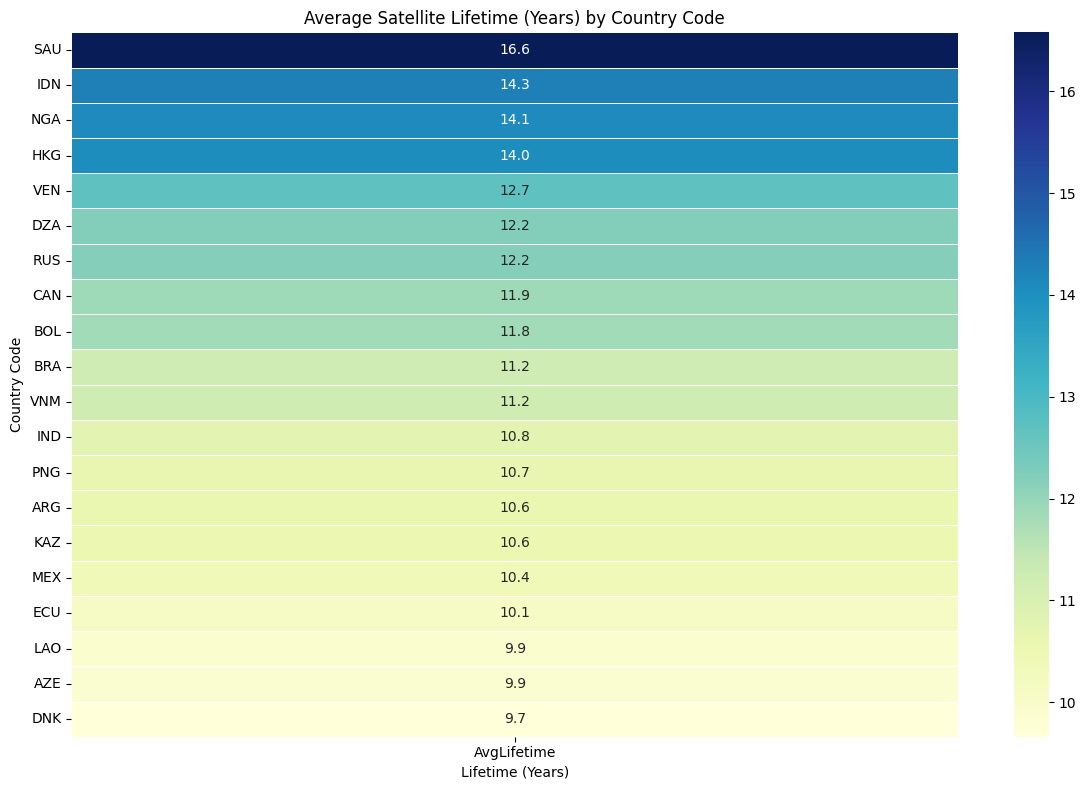

In [476]:

# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(
    avg_lifetime.set_index('CountryCode'),
    annot=True,
    cmap='YlGnBu',
    fmt=".1f",
    linewidths=0.5,
)
plt.title('Average Satellite Lifetime (Years) by Country Code')
plt.ylabel('Country Code')
plt.xlabel('Lifetime (Years)')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

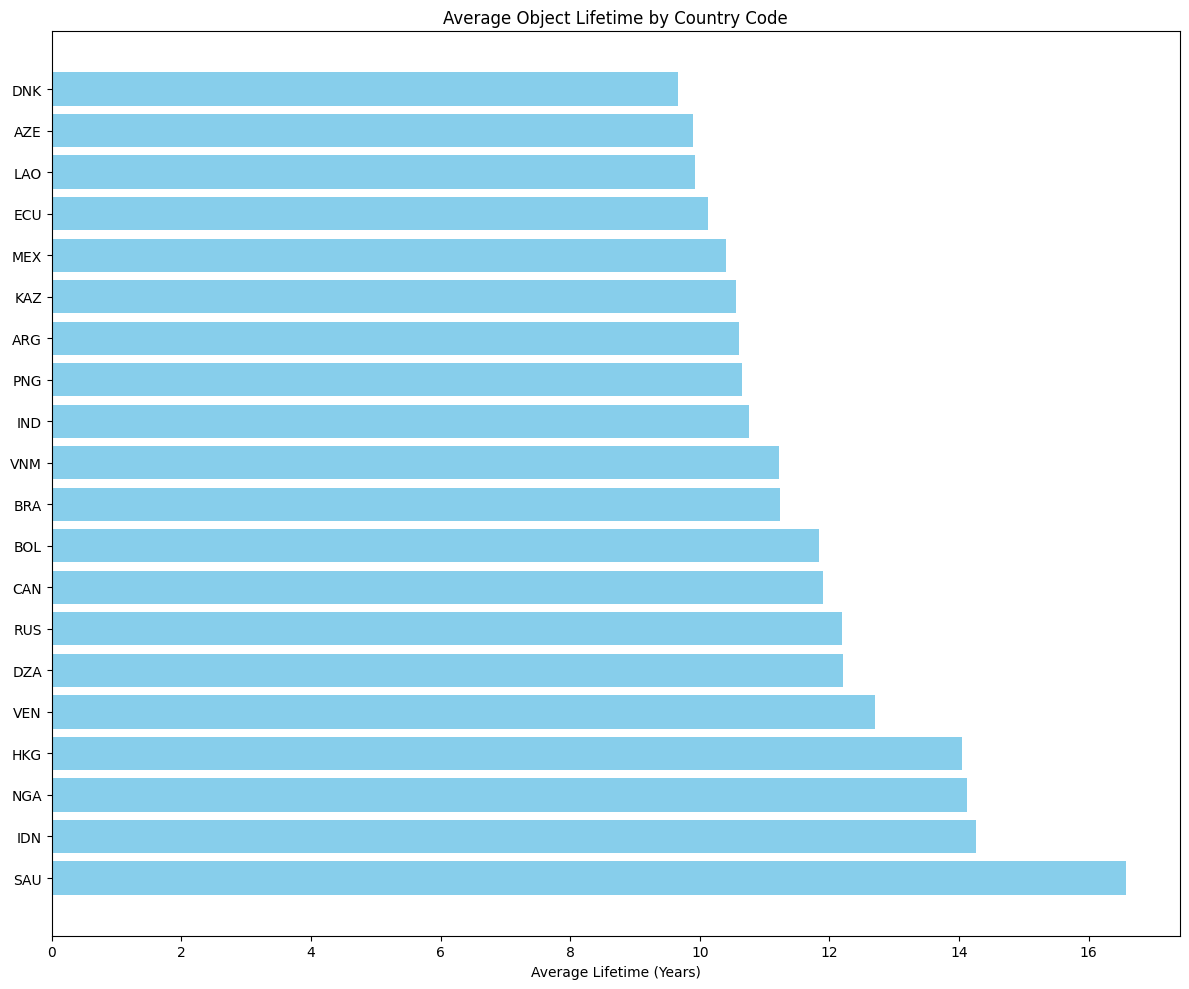

In [473]:
plt.figure(figsize=(12, 10))
plt.barh(avg_lifetime['CountryCode'], avg_lifetime['AvgLifetime'], color='skyblue')
plt.xlabel('Average Lifetime (Years)')
plt.title('Average Object Lifetime by Country Code')
plt.tight_layout()
plt.show()

In [430]:
# Filter non payloads
# sdf = sdf[sdf['Type'].str.startswith('P', na=False)]

<Figure size 1500x800 with 0 Axes>

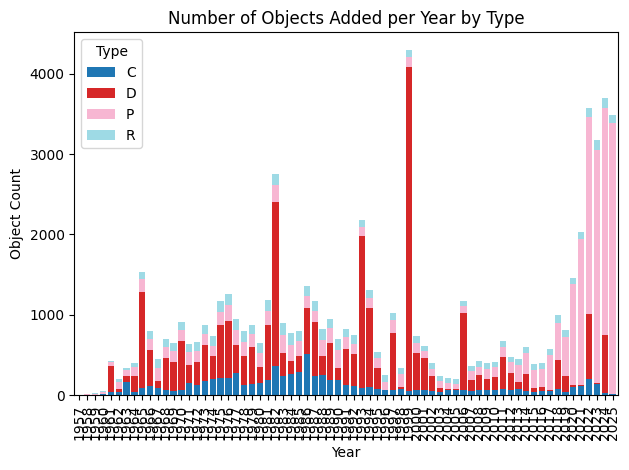

In [431]:
# Group by LYear and Type, then count
grouped = sdf.groupby(['LYear', 'Type']).size().unstack(fill_value=0).sort_index()

# Plotting
plt.figure(figsize=(15, 8))
grouped.plot(kind='bar', stacked=True, colormap='tab20', width=0.8)
plt.title('Number of Objects Added per Year by Type')
plt.xlabel('Year')
plt.ylabel('Object Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

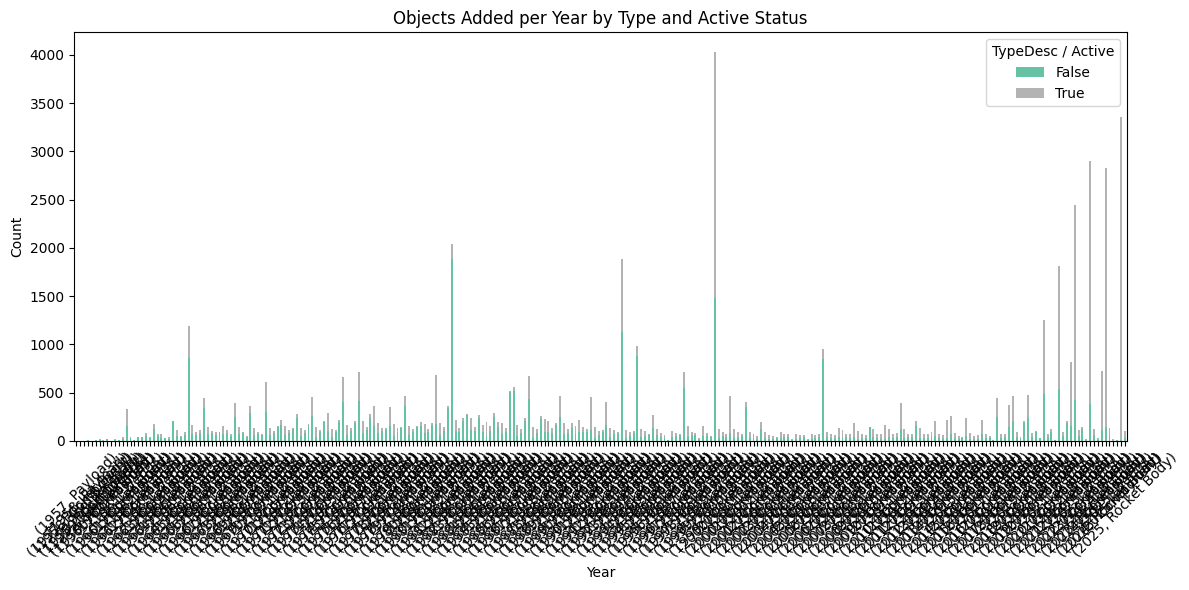

In [432]:
grouped = sdf.groupby(['LYear', 'TypeDesc', 'Active']).size().unstack(fill_value=0)

# Plotting
grouped.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2')
plt.title('Objects Added per Year by Type and Active Status')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='TypeDesc / Active')
plt.tight_layout()
plt.show()

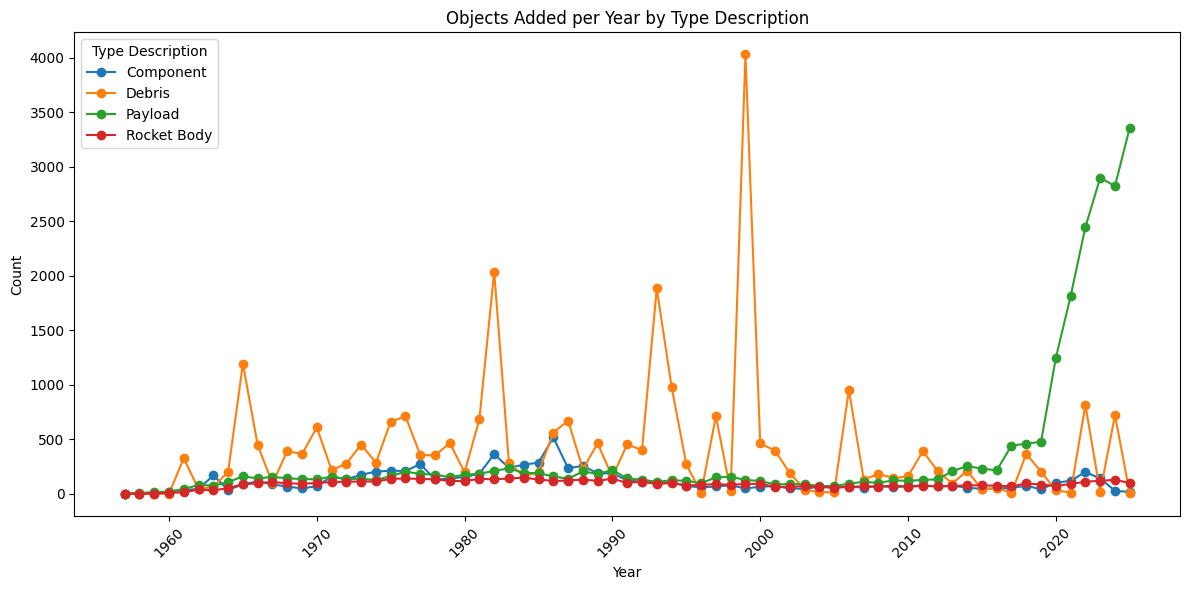

In [433]:
grouped = sdf.groupby(['LYear', 'TypeDesc']).size().unstack(fill_value=0).sort_index()

grouped.plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Objects Added per Year by Type Description')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Type Description')
plt.tight_layout()
plt.show()

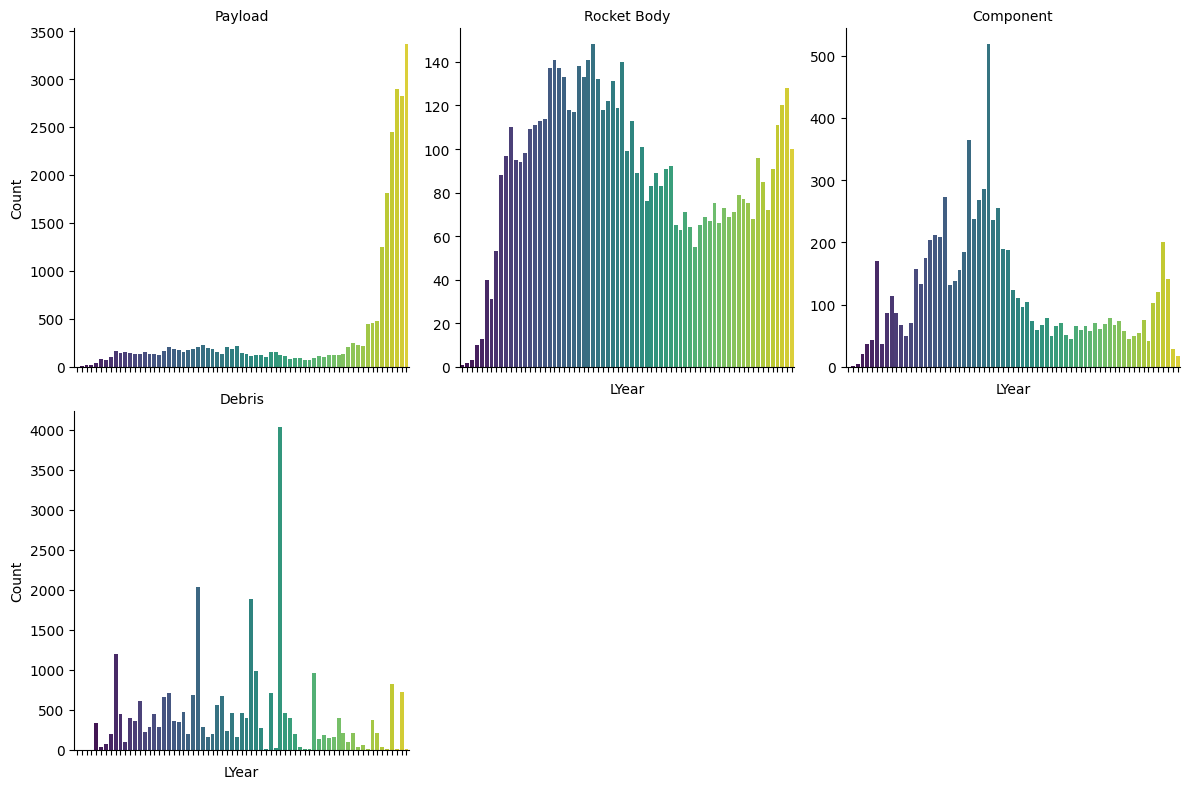

In [434]:
melted = sdf.groupby(['LYear', 'TypeDesc']).size().reset_index(name='Count')

# Plot
g = sns.FacetGrid(melted, col='TypeDesc', col_wrap=3, height=4, sharey=False)
g.map_dataframe(sns.barplot, x='LYear', y='Count', palette='viridis')
g.set_titles(col_template='{col_name}')
g.set_xticklabels(rotation=45)
plt.tight_layout()
plt.show()

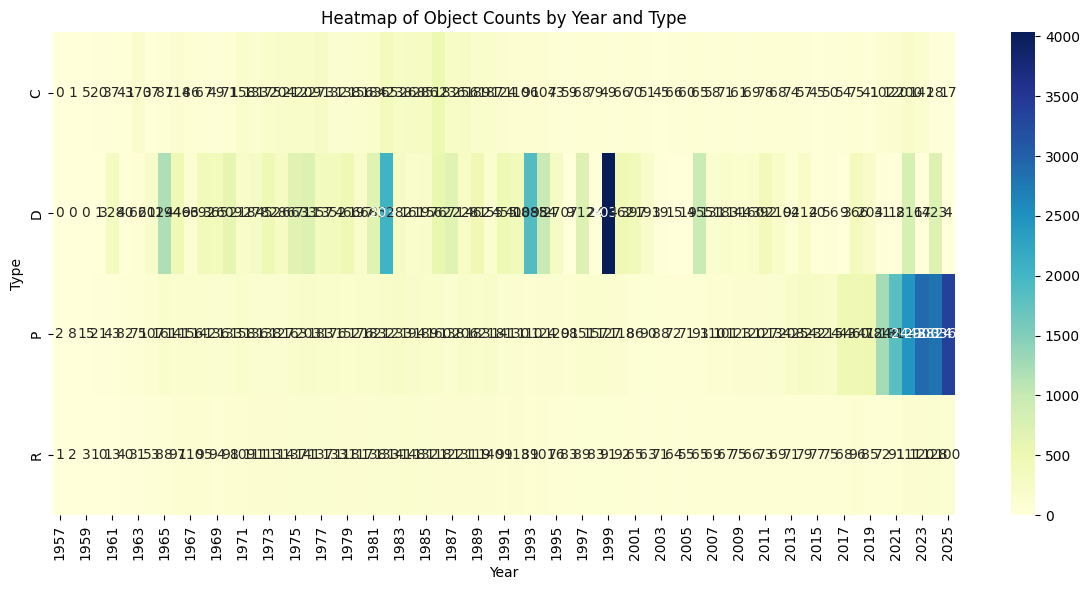

In [435]:
heatmap_data = sdf.groupby(['LYear', 'Type']).size().unstack(fill_value=0).sort_index()

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data.T, cmap='YlGnBu', annot=True, fmt='d')
plt.title('Heatmap of Object Counts by Year and Type')
plt.xlabel('Year')
plt.ylabel('Type')
plt.tight_layout()
plt.show()

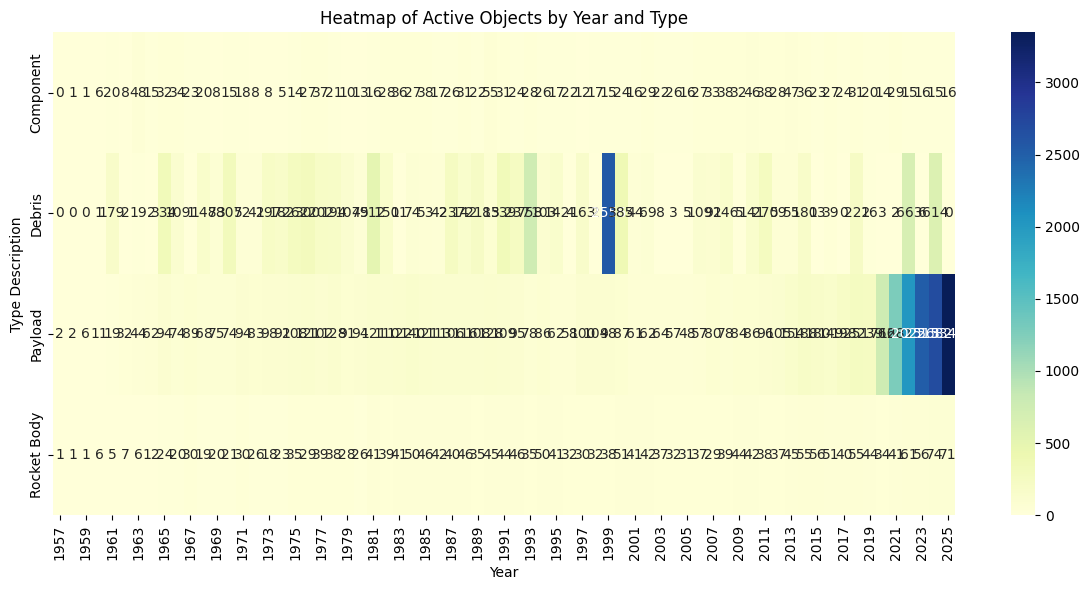

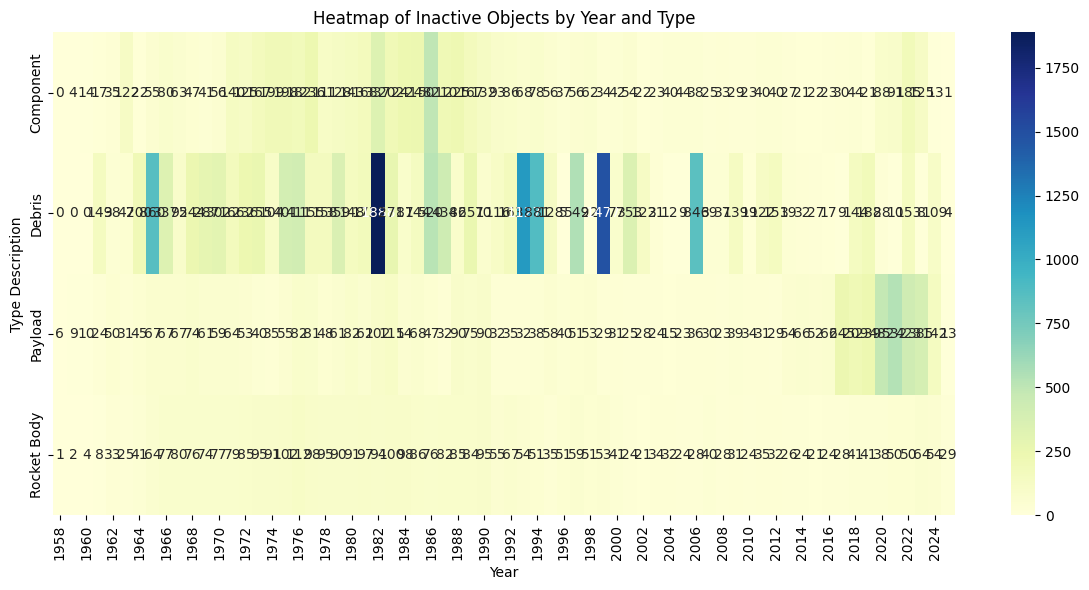

In [436]:
for status in [True, False]:
    subset = sdf[sdf['Active'] == status]
    heatmap_data = subset.groupby(['LYear', 'TypeDesc']).size().unstack(fill_value=0)

    plt.figure(figsize=(12, 6))
    sns.heatmap(heatmap_data.T, cmap='YlGnBu', annot=True, fmt='d')
    plt.title(f"Heatmap of {'Active' if status else 'Inactive'} Objects by Year and Type")
    plt.xlabel('Year')
    plt.ylabel('Type Description')
    plt.tight_layout()
    plt.show()

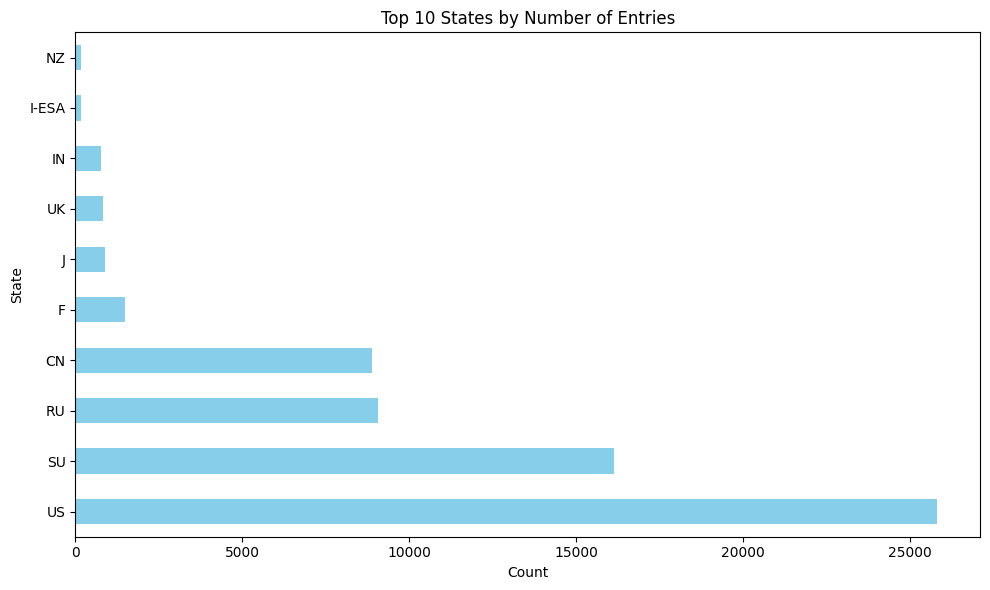

In [437]:
state_counts = sdf['State'].value_counts().head(10)

# Plotting a horizontal bar chart
plt.figure(figsize=(10, 6))
state_counts.plot(kind='barh', color='skyblue')
plt.title('Top 10 States by Number of Entries')
plt.xlabel('Count')
plt.ylabel('State')
plt.tight_layout()
plt.show()

In [438]:
owner_counts = sdf['Owner'].value_counts().reset_index()
owner_counts.columns = ['Owner', 'Count']
display(owner_counts)

,Owner,Count
0,SPXS,10313
1,CASC,4351
2,RVSN,4063
3,KVR,3116
4,GSFC,3107
...,...,...
1863,HYDRA/ICH,1
1864,HYDRA,1
1865,ARC/WI,1
1866,IMBP/GUKOSR,1


In [439]:
orgs_df.columns

Index(['#Code', 'UCode', 'StateCode', 'Type', 'Class', 'TStart', 'TStop',
       'ShortName', 'Name', 'Location', 'Longitude', 'Latitude', 'Error',
       'Parent', 'ShortEName', 'EName', 'UName'],
      dtype='object')

In [440]:
orgs_df.sample(n=20)

,#Code,UCode,StateCode,Type,Class,TStart,TStop,ShortName,Name,Location,Longitude,Latitude,Error,Parent,ShortEName,EName,UName
2433,NPKSPP,NIIPP,SU,O/PL,C,2009 Oct 16,-,AO NPK SPP,"AO Nauchno-proizvodstvennaya Korp.""Sistemi Pre...",Mosvka,37.6200,55.7500,0.02,-,IPIE,Institute for Precision Instrument Engineering,АО «НПК «СПП»
3492,TULF,TULF,TR,O/LA,D,1949,-,Turkish Army,Turk Kara Kuvvetleri,Ankara,32.8700,39.9300,0.02,-,-,Turkish Land Forces,Türk Kara Kuvvetleri
3678,USU,USU,US,O/PL/S,A,1959,-,USU SDL,"Utah State University, Space Dynamics Lab, (SDL)","Logan, Utah",-111.8300,41.7400,0.02,-,-,-,"Utah State University, Space Dynamics Lab, (SDL)"
3893,ZBEU,ZBEU,TR,O/PL,A,1992,-,ZBEU,Zonguldak Bulent Ecevit Universitesi,Zonguldak,31.7600,41.4500,0.02,-,-,Zonguldak Bulent Ecevit University,Zonguldak Bülent Ecevit Üniversitesi
2188,MICORB,MICORB,J,O/PL,B,2021 May,-,Micro Orbiter,Kabushikigaisha Maikuroobita,Tokyo:Chiyoda,139.7600,35.6800,0.02,-,-,Micro Orbiter Inc.,株式会社マイクロオービター
2801,QIZH,LAND,CN,O,B,2018,-,Qizhou Group,Beijing Qizhong Keji Fazhan Jituan YG,Beijing,116.3800,39.9200,0.02,-,-,Qizhong Group,北京其中科技发展集团有限公司
795,BREI,BREI,D,PL/S,A,1947,-,Breisach,Ionospharen Institut Breisach,"Breisach, Baden-Wutternberg",7.5800,48.0300,0.02,-,-,Ionosphere Research Insitute,Ionosphäreninstitut Breisach
505,AMCOM,ABMA,US,-,D,1997 Oct,-,USA AMCOM,US Army Aviation and Missile Command,"Huntsville, Alabama",-86.6500,34.6800,0.02,USA,-,-,US Army Aviation and Missile Command
3363,TELK,PER,ID,O,B,1991,-,Telkom,PT Telekomunikasi Indonesia Tbk (Telkom),Jakarta,106.8200,-6.2000,0.02,-,-,PT Telecommunications of Indonesia,PT Telekomunikasi Indonesia Tbk (Telkom)
923,CHUNG,CHUNG,TW,-,B,1996,-,Chunghwa Tel,Chunghwa Telecom (Chung-hua Tien-hsin),Taipei,120.9800,24.8200,0.02,-,-,Chunghaw Telecom,中華電信


In [441]:
orgs_columns_to_keep = ['#Code', 'UCode', 'ShortName', 'Name', 'EName', 'Longitude', 'Latitude', 'Parent']
odf = orgs_df[orgs_columns_to_keep]
odf.columns

Index(['#Code', 'UCode', 'ShortName', 'Name', 'EName', 'Longitude', 'Latitude',
       'Parent'],
      dtype='object')

In [442]:
# First, rename odf columns for owner merge
owner_odf = odf.rename(columns=lambda x: f'owner_{x}' if x != '#Code' else 'Owner')

# Merge owner info
sdf = sdf.merge(owner_odf, on='Owner', how='left')

# Optional: repeat for manufacturer with a different prefix
manufacturer_odf = odf.rename(columns=lambda x: f'manu_{x}' if x != '#Code' else 'Manufacturer')
sdf = sdf.merge(manufacturer_odf, on='Manufacturer', how='left')


In [443]:
sdf.columns

Index(['Piece', 'Type', 'Name', 'LDate', 'DDate', 'Status', 'Owner', 'State',
       'Manufacturer', 'Mass', 'Length', 'Diameter', 'Span', 'Shape',
       'Perigee', 'Apogee', 'Inc', 'LYear', 'DYear', 'EffectiveDDate',
       'ActiveDays', 'ActiveMonths', 'ActiveYears', 'CountryCode', 'TypeDesc',
       'Active', 'owner_UCode', 'owner_ShortName', 'owner_Name', 'owner_EName',
       'owner_Longitude', 'owner_Latitude', 'owner_Parent', 'manu_UCode',
       'manu_ShortName', 'manu_Name', 'manu_EName', 'manu_Longitude',
       'manu_Latitude', 'manu_Parent'],
      dtype='object')

In [444]:
sdf.sample(10)

,Piece,Type,Name,LDate,DDate,Status,Owner,State,Manufacturer,Mass,...,owner_Longitude,owner_Latitude,owner_Parent,manu_UCode,manu_ShortName,manu_Name,manu_EName,manu_Longitude,manu_Latitude,manu_Parent
8884,1976-054B,P,Kosmos-826,15/06/1976,NaN,O,GUKOSR,SU,OKB10,60.0,...,37.6200,55.7500,RVSN,NPOPM,OKB-10,OKB-10 (Reshetnev),-,93.5300,56.2500,-
34974,1993-036AFW,D,deb Kosmos-2251,16/06/1993,NaN,O,KVR,RU,-,0,...,36.9800,56.1800,MORF,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15198,1984-089B,R,Molniya-M 12-661 Blok-I,24/08/1984,17/09/1984,R,RVSN,SU,PROG,2350.0,...,37.6200,55.7500,MO,PROG,Progress,Zavod Progress,Progress Factory,50.1400,53.2000,-
14102,1983-052G,C,KDU part,31/05/1983,19/06/1983,R,GUKOS,SU,TSSKB,0.0,...,37.6200,55.7500,MO,TSSKB,TsSKB,Tsentral'nogo Spetsializirovannogo Konstruktor...,Central Specialized Design Bureau,50.1400,53.2000,-
42166,1981-053TE,D,deb Kosmos-1275,04/06/1981,NaN,OX,GUKOS,RU,-,0,...,37.6200,55.7500,MO,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21281,1991-033C,P,Kosmos-2145,16/05/1991,NaN,O,UNKSR,SU,NPOPM,225.0,...,37.6200,55.7500,RVSNR,NPOPM,NPO PM,NPO Prikladnoi Mekhaniki,NPO Applied Mechanics,93.5300,56.2500,MOM
6050,1972-040C,C,Blenda?,09/06/1972,24/06/1972,R,GUKOSR,SU,TSKBE3,20.0,...,37.6200,55.7500,RVSN,TSSKB,TsKBEM Fil. 3,TsKBEM Filial No. 3,-,50.1400,53.2000,TSKBEM
22780,1993-050C,C,NOAA 13 solar array band?,09/08/1993,08/04/2022,R,GSFC,US,-,0.0,...,-76.8900,38.9900,NASA,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21107,1990-105AC,D,deb Star 37S,01/12/1990,08/04/1991,R,AFSSD2,US,-,0.0,...,-118.4100,33.9200,USAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11728,1980-023A,P,Kosmos-1169,27/03/1980,03/03/1983,R,PVO,SU,YUZH,570.0,...,37.6200,55.7500,-,YUZH,Yuzhnoe,KB Yuzhnoe im. M K Yangel,Southern State Design Bureau,34.9800,48.4500,-


In [445]:
pay_df.columns

Index(['#JCAT', 'Piece', 'Name', 'LDate', 'TLast', 'TOp', 'TDate', 'TF',
       'Program', 'Plane', 'Att', 'Mvr', 'Class', 'Category', 'Result',
       'Control', 'Discipline', 'UNState', 'UNReg', 'UNPeriod', 'UNPerigee',
       'UNApogee', 'UNInc', 'DispEpoch', 'DispPeri', 'DispApo', 'DispInc',
       'Comment'],
      dtype='object')

In [446]:
payload_columns_to_keep = ['Piece', 'Program', 'Class', 'Category']
pdf = pay_df[payload_columns_to_keep]
pdf.columns

Index(['Piece', 'Program', 'Class', 'Category'], dtype='object')

In [447]:
sdf = sdf.merge(pdf, on='Piece', how='left')

In [448]:
sdf.columns

Index(['Piece', 'Type', 'Name', 'LDate', 'DDate', 'Status', 'Owner', 'State',
       'Manufacturer', 'Mass', 'Length', 'Diameter', 'Span', 'Shape',
       'Perigee', 'Apogee', 'Inc', 'LYear', 'DYear', 'EffectiveDDate',
       'ActiveDays', 'ActiveMonths', 'ActiveYears', 'CountryCode', 'TypeDesc',
       'Active', 'owner_UCode', 'owner_ShortName', 'owner_Name', 'owner_EName',
       'owner_Longitude', 'owner_Latitude', 'owner_Parent', 'manu_UCode',
       'manu_ShortName', 'manu_Name', 'manu_EName', 'manu_Longitude',
       'manu_Latitude', 'manu_Parent', 'Program', 'Class', 'Category'],
      dtype='object')

In [449]:
sdf.sample(10)

,Piece,Type,Name,LDate,DDate,Status,Owner,State,Manufacturer,Mass,...,manu_UCode,manu_ShortName,manu_Name,manu_EName,manu_Longitude,manu_Latitude,manu_Parent,Program,Class,Category
65815,2025-224U,P,Starlink 35264,07/10/2025,NaN,O,SPXS,US,SPXS,575.0,...,SPXS,SpaceX/Seattle,SpaceX (Seattle),-,-122.1200,47.6700,-,Starlink 2MO S1,B,COM
18829,1988-006C,C,DMSP F-9 solar array band?,03/02/1988,12/03/1992,R,AFSD,US,-,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27837,1964-049S,D,deb Kosmos-41,22/08/1964,19/06/2005,R,RKKE,RU,-,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55524,2023-020AE,P,Starlink 5743,12/02/2023,NaN,O,SPXS,US,SPXS,305,...,SPXS,SpaceX/Seattle,SpaceX (Seattle),-,-122.1200,47.6700,-,Starlink 1.5 G5,B,COM
15179,1982-033CM,C,Garbage bag,19/04/1982,04/10/1984,R,NPOE,SU,-,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22857,1993-068B,R,Delta 223,26/10/1993,18/09/1999,R,MDAC,US,MDAC,6930.0,...,DACHB,MDAC-HB,McDonnell Douglas Astronautics Co.,McDonnell Douglas Astronautics/HB,-118.0000,33.6900,MDC,NaN,NaN,NaN
37937,1993-036BPL,D,deb Kosmos-2251,16/06/1993,NaN,O,KVR,RU,-,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37750,2011-040B,R,Centaur AV-029,05/08/2011,05/08/2011,DSO,LMSSD,US,ULAD,7950,...,ULAD,ULA Decatur,"United Launch Alliance, Decatur",-,-86.9800,34.6100,ULAL,NaN,NaN,NaN
27183,2001-049FB,D,deb PSLV-C3 PS4,22/10/2001,30/03/2002,R,ISRO,IN,LPSC,0.0,...,LPSC,VSSC/LPSC,VSSC Liquid Propulsion Systems Center,-,76.8700,8.5300,-,NaN,NaN,NaN
4432,1969-082EE,D,deb Agena D,30/09/1969,19/04/1979,R,SAMSO,US,-,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


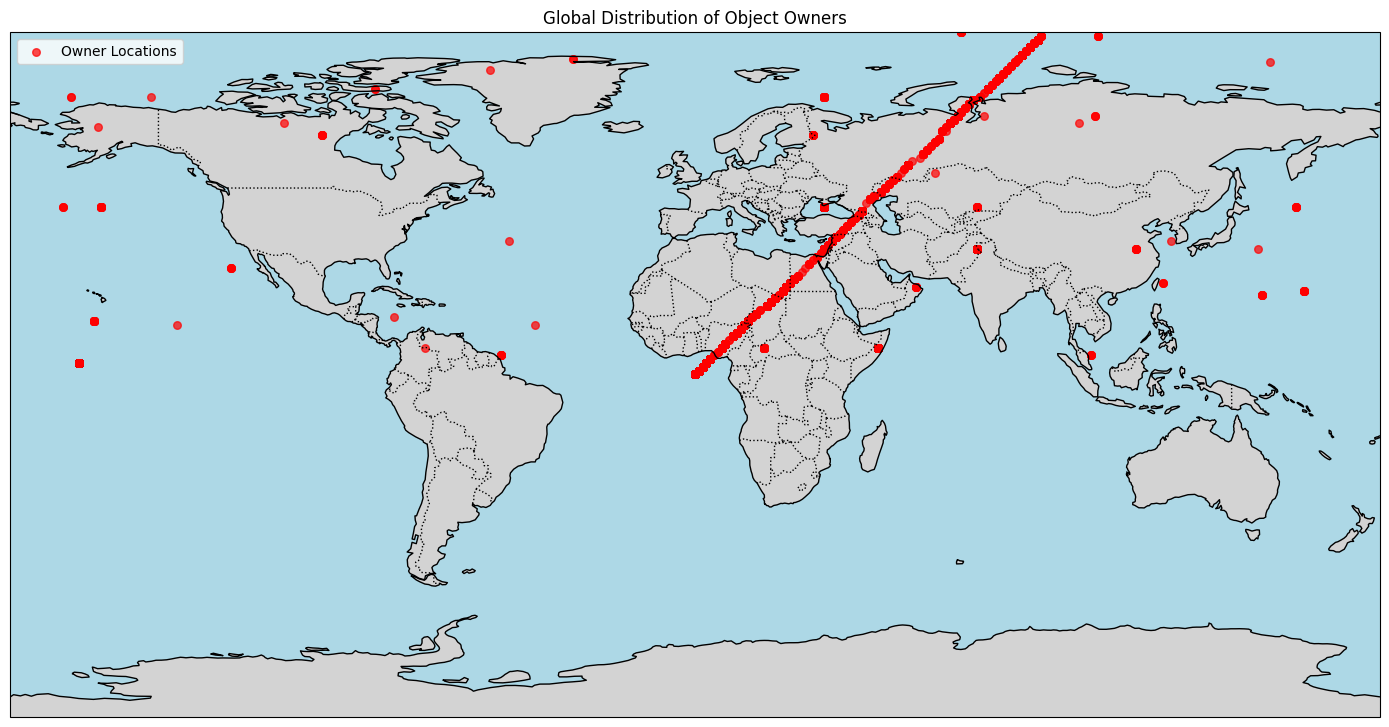

In [450]:
# Drop rows with missing coordinates
sdf_clean = sdf.dropna(subset=['owner_Latitude', 'owner_Longitude'])

# Create the map
plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

# Plot points
ax.scatter(
    sdf_clean['owner_Longitude'],
    sdf_clean['owner_Latitude'],
    color='red',
    s=30,
    alpha=0.7,
    transform=ccrs.PlateCarree(),
    label='Owner Locations'
)

plt.title('Global Distribution of Object Owners')
plt.legend()
plt.tight_layout()
plt.show()

In [480]:
world = gpd.read_file("ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")


In [481]:
# Count satellites per country
state_counts = sdf['CountryCode'].value_counts().reset_index()

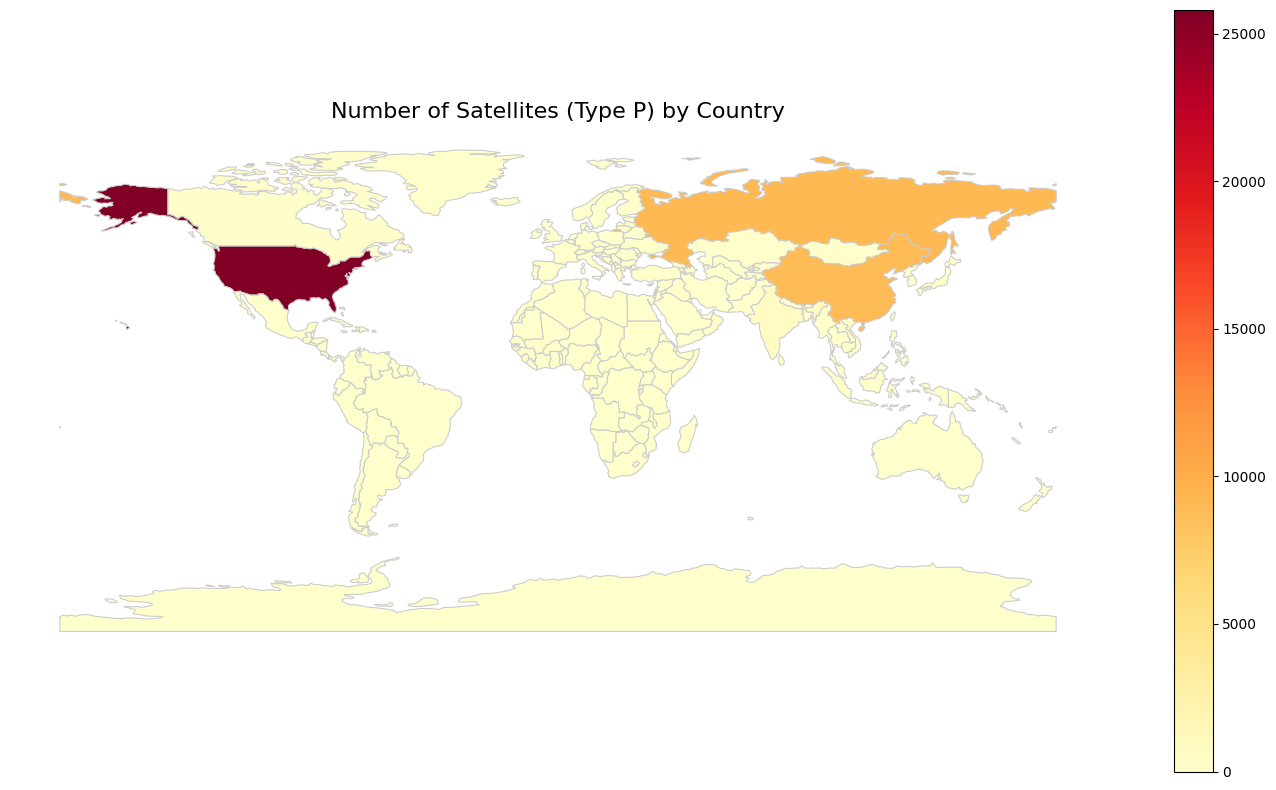

In [482]:


state_counts.columns = ['ADM0_ISO', 'SatelliteCount']

# Load world map with ISO codes
world = gpd.read_file("ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")
#world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Merge using ISO alpha-3 codes
merged = world.merge(state_counts, on='ADM0_ISO', how='left')

# Fill missing counts with 0
merged['SatelliteCount'] = merged['SatelliteCount'].fillna(0)

# Plotting
fig, ax = plt.subplots(figsize=(14, 8))
merged.plot(column='SatelliteCount', cmap='YlOrRd', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
ax.set_title('Number of Satellites (Type P) by Country', fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()

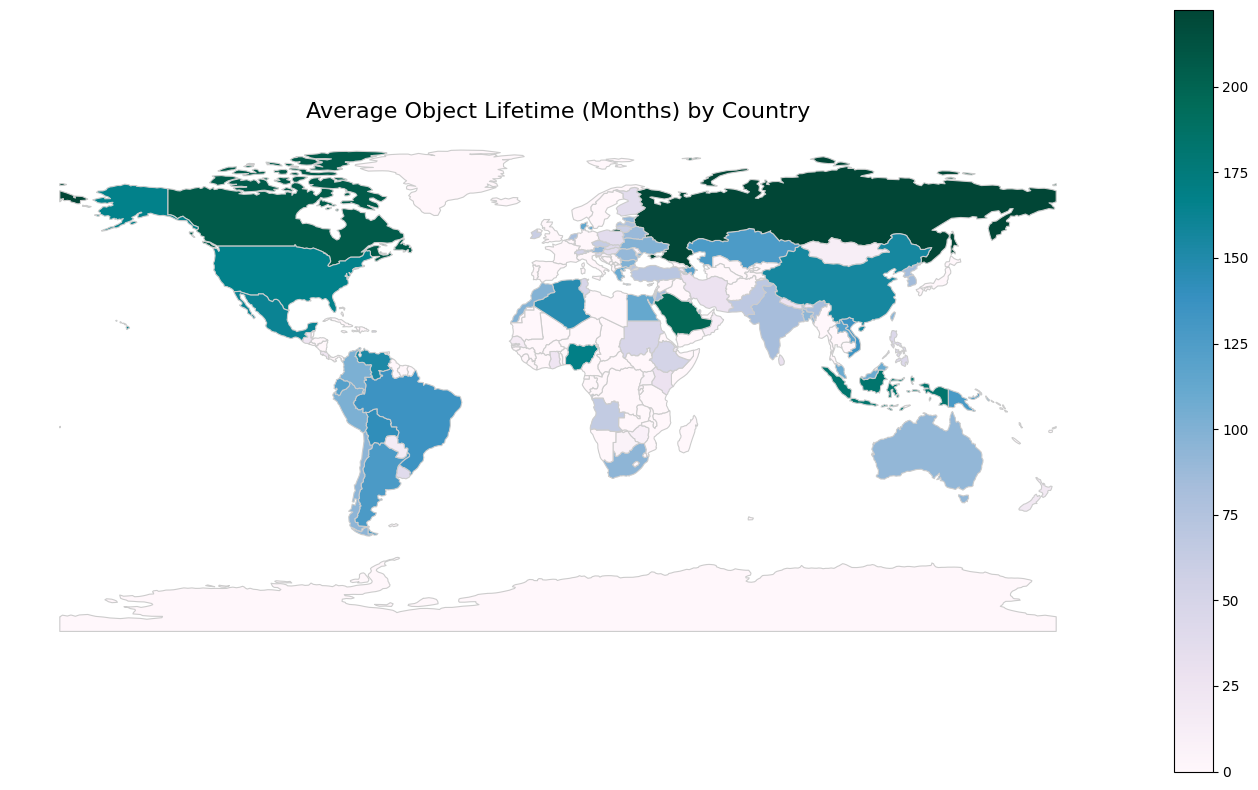

In [484]:
avg_months = sdf.groupby('CountryCode')['ActiveMonths'].mean().reset_index()
avg_months.columns = ['ADM0_A3', 'AvgMonths']
merged = world.merge(avg_months, on='ADM0_A3', how='left')
merged['AvgMonths'] = merged['AvgMonths'].fillna(0)
fig, ax = plt.subplots(figsize=(14, 8))
merged.plot(column='AvgMonths', cmap='PuBuGn', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
ax.set_title('Average Object Lifetime (Months) by Country', fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()